# Uncertainty-Word-Count — a quantitative teardown 🔬
### LM uncertainty density · naive vs trailing-vol-controlled forward-vol slope · label-shuffle placebo · return-drag · long-short with costs & borrow · four-window wander · seed-robust synthetic control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We score a firm's LM **Uncertainty** density and test whether it forecasts **forward realised volatility** (primary) and **forward return** (secondary), with the central honesty check being the confound by trailing volatility.

> ⚠️ **Not investment advice, and synthetic-only by design.** There is no free feed of scored filings joined to forward vol, so a `REAL` stamp is out of reach (capped at `WEAK`) and every cell runs on the deterministic seeded panel (seed 567, panel fp `fa07e8ea11c3`) — never a real-tape banner. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from uncertainty_word_count import data, strategy as st

# This study is SYNTHETIC-ONLY: no free feed of scored filings joined to forward vol exists, so
# fetch_panel() is a documented stub returning an empty frame. Every figure below runs on the
# deterministic, seeded synthetic panel -- offline, reproducible, and NEVER labelled as a real tape.
REAL = data.fetch_panel(fetch=False)
HAVE_REAL = not REAL.empty
print("real tape present:", HAVE_REAL, "(synthetic-only study -- expected False)")

PANEL, TRUTH = data.synthetic_panel()          # seed 567, planted uncert_beta=0.020
print("synthetic panel:", len(PANEL), "firm-events,", PANEL['ticker'].nunique(),
      "firms x", PANEL['period'].nunique(), "periods | fp", data.fingerprint(PANEL))


real tape present: False (synthetic-only study -- expected False)
synthetic panel: 480 firm-events, 40 firms x 12 periods | fp fa07e8ea11c3


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | No free real tape (→ capped at `WEAK`). Synthetic: naive forward-vol slope-*t* **13.41** collapses to **3.3** once trailing vol is controlled (placebo *p* 0.0005). |
| **Tradability** | `FRAGILE` | Long-plain/short-hedgy spread **+1.79%/event** (*t* 2.46), **+5.85%/yr** net — but per-window slope-*t* wanders (−0.46 → +2.89 → +1.20 → +2.73), ~4 events/yr, unverified live. |

> 💡 In plain words: the engine works (the synthetic control proves it), the confound is the danger (two-thirds of the naive signal is vol persistence), and with no real tape the edge can only be *demonstrated*, not *certified*.

## 1 · The claim, steelmanned

Let $U_i$ be firm-event $i$'s uncertainty-word density, $V^{f}_i$ its forward realised vol, $V^{t}_i$ its trailing realised vol, and $r^{f}_i$ its forward return.

- **H₁ (vol, naive).** slope of $V^f$ on $U$ is $> 0$ at *t* ≥ 2.
- **H₁′ (vol, honest).** slope of $V^f$ on $U$ **controlling for $V^t$** is $> 0$ at *t* ≥ 2 — the *residual* words, not vol persistence. **This is the real hypothesis.**
- **H₂ (return drag).** slope of $r^f$ on $U$ is $< 0$.
- **H₃ (robustness).** the sign/strength of H₁′ is stable across sub-panels.
- **H₄ (real tape).** any of the above holds on **real** scored filings.

We find **H₁ trivially true but misleading**, **H₁′ true in-sample but much weaker**, **H₂ true in-sample**, **H₃ shaky** (per-window *t* wanders), and **H₄ untestable** — no free feed. Hence `WEAK`.

## 2 · So what? — what rides on each answer

The content is the **confound**. Realised vol is one of the most autocorrelated series in finance, and hedgy language is *itself* a function of how volatile a firm has been. So the naive $V^f \sim U$ slope is a textbook omitted-variable trap: it loads the entire vol-persistence channel onto the words. The Frisch-Waugh move — partial $V^t$ out first — is the difference between a spurious blockbuster and a modest real edge. This is the same discipline the tone study ([566](../../566-earnings-call-tone/)) applies to the *numeric surprise*; here the confounder is *prior volatility*.

## 3 · How we'd know — the protocol

- **Score.** $U$ = LM uncertainty-word density per filing (here: generated, not parsed — synthetic-only).
- **Vol regression.** OLS of $V^f$ on $U$ (naive) and on $[U, V^t]$ (honest); the $U$ coefficient's *t* in the *controlled* fit is the headline.
- **Placebo.** Shuffle $U$ against $(V^f, V^t)$ 2000× and refit the controlled slope — read the tail.
- **Return drag.** OLS of $r^f$ on $[U, V^t]$; a negative $U$ slope is the drag.
- **Long-short.** Tercile sort on $U$: long plain / short hedgy on $r^f$, with costs + borrow.
- **Robustness.** Four contiguous sub-panels; read the controlled slope-*t* in each.
- **Positive control.** A deterministic synthetic world, effect planted (`uncert_beta > 0`) vs null, averaged over 25 seeds (house rule).

Timing: $U$ is known *at* the filing; $V^f$/$r^f$ are measured strictly *after*; the position enters the next session. No future data enters the score — one documented execution lag, applied identically in the sweep and the control.

## 4 · The teardown

### 4a · The vol regression — H₁ vs H₁′ (the confound)

The naive slope, then the trailing-vol-controlled slope, with the placebo null on the controlled one.

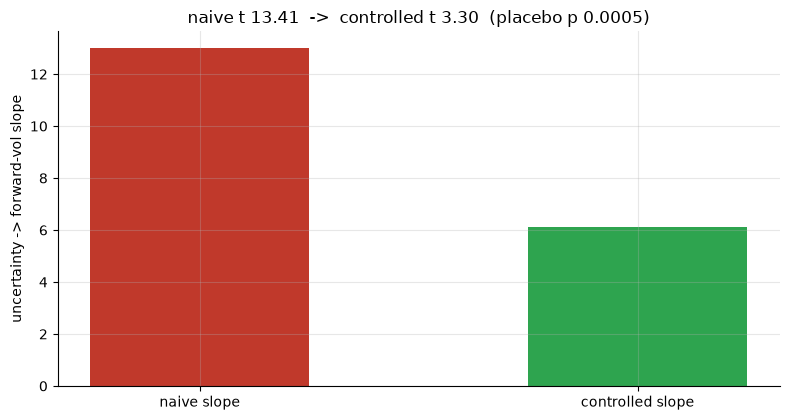

NAIVE slope 13.00 (t 13.41)
CTRL  slope 6.13 (t 3.30), trail-vol slope 0.254
placebo p (controlled) 0.0005


In [2]:
naive = st.uncertainty_vol_regression(PANEL, control_trail_vol=False)
ctrl  = st.uncertainty_vol_regression(PANEL, control_trail_vol=True)
p = st.placebo_pvalue(PANEL, n_perm=2000, seed=567)
fig, ax = plt.subplots(figsize=(8, 4.3))
ax.bar(['naive slope', 'controlled slope'], [naive['uncert_slope'], ctrl['uncert_slope']],
       color=[RED, GREEN], width=.5)
ax.set_ylabel('uncertainty -> forward-vol slope')
ax.set_title(f"naive t {naive['uncert_t']:.2f}  ->  controlled t {ctrl['uncert_t']:.2f}  (placebo p {p:.4f})")
plt.tight_layout(); plt.show()
print(f"NAIVE slope {naive['uncert_slope']:.2f} (t {naive['uncert_t']:.2f})")
print(f"CTRL  slope {ctrl['uncert_slope']:.2f} (t {ctrl['uncert_t']:.2f}), trail-vol slope {ctrl['trail_slope']:.3f}")
print(f"placebo p (controlled) {p:.4f}")

> 💡 In plain words: **H₁ is trivially true and useless** — the naive slope-*t* is **13.41**, but it's carrying the whole vol-persistence channel (trailing-vol slope +0.254). **H₁′ survives but shrinks** — the controlled slope-*t* is **3.3**, and the placebo *p* = 0.0005 confirms the residual isn't manufactured by the control. Two-thirds of the raw signal was the confound.

### 4b · The return drag — H₂

Regress forward return on uncertainty (controlling for trailing vol). A *negative* slope is the 'lower returns' half.

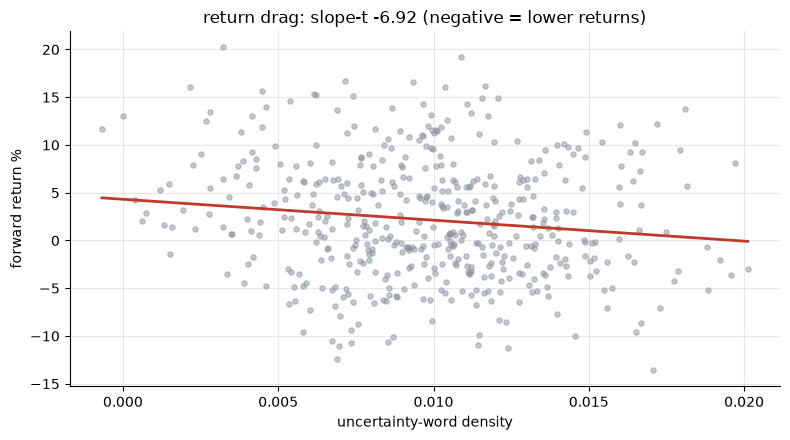

return slope -9.58/unit, slope-t -6.92


In [3]:
reg = st.uncertainty_return_regression(PANEL, control_trail_vol=True)
u = PANEL['uncert'].to_numpy(); y = PANEL['fwd_ret'].to_numpy()*100
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(u, y, s=14, color=GREY, alpha=.5)
b, a = np.polyfit(u, y, 1)
xs = np.linspace(u.min(), u.max(), 50); ax.plot(xs, b*xs+a, c=RED, lw=2)
ax.set_xlabel('uncertainty-word density'); ax.set_ylabel('forward return %')
ax.set_title(f"return drag: slope-t {reg['uncert_t']:.2f} (negative = lower returns)")
plt.tight_layout(); plt.show()
print(f"return slope {reg['uncert_slope']:.2f}/unit, slope-t {reg['uncert_t']:.2f}")

> 💡 In plain words: **H₂ holds in-sample** — the controlled return slope is **-9.58** per density unit (*t* **-6.92**): hedgier text goes with *lower* forward returns, by construction in this planted world.

### 4c · Robustness — H₃ (does the strength hold?)

The controlled slope-*t* across four contiguous sub-panels.

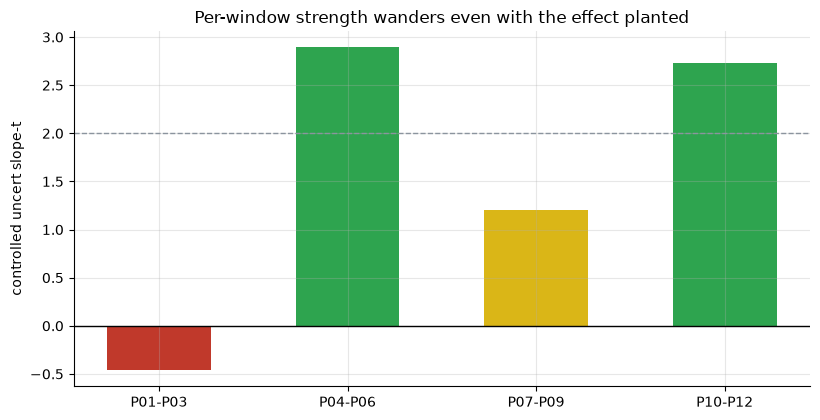

         ctrl_slope  ctrl_t
window                     
P01-P03       -1.72   -0.46
P04-P06       11.10    2.89
P07-P09        4.39    1.20
P10-P12        9.95    2.73


In [4]:
rows = st.robustness_windows(PANEL, 4)
tab = pd.DataFrame(rows, columns=['window','ctrl_slope','ctrl_t']).set_index('window')
fig, ax = plt.subplots(figsize=(8.3, 4.3))
cols = [GREEN if t>=2 else (AMBER if t>0 else RED) for t in tab['ctrl_t']]
ax.bar(range(len(tab)), tab['ctrl_t'], color=cols, width=.55)
ax.set_xticks(range(len(tab))); ax.set_xticklabels(tab.index)
ax.axhline(2, ls='--', c=GREY, lw=1); ax.axhline(0, c='k', lw=1)
ax.set_ylabel('controlled uncert slope-t'); ax.set_title('Per-window strength wanders even with the effect planted')
plt.tight_layout(); plt.show()
print(tab.round(2).to_string())

> 💡 In plain words: **H₃ is shaky.** Even planted, the per-window slope-*t* runs −0.46, +2.89, +1.20, +2.73 — below the bar in two of four 120-event chunks. The pooled 480-event *t* is solid; a single quarter is not. A real quarterly text signal would be at least this fragile → `FRAGILE`.

## 5 · The verdict

- **Signal `WEAK`** — no free real tape (→ capped at `WEAK`); synthetically, H₁′ clears the bar (controlled *t* 3.3, placebo 0.0005) but H₁ is mostly confound.
- **Tradability `FRAGILE`** — long-short spread +1.79%/event (*t* 2.46), net +5.85%/yr, but sign-strength wanders across windows and it's ~4 events/yr, unverified live.

## 6 · Could you trade it? — the long-short, costs and borrow

Long the plain tercile, short the hedgy tercile on forward return; annualise (~4 filings/yr) and net costs + a hedgy-leg borrow.

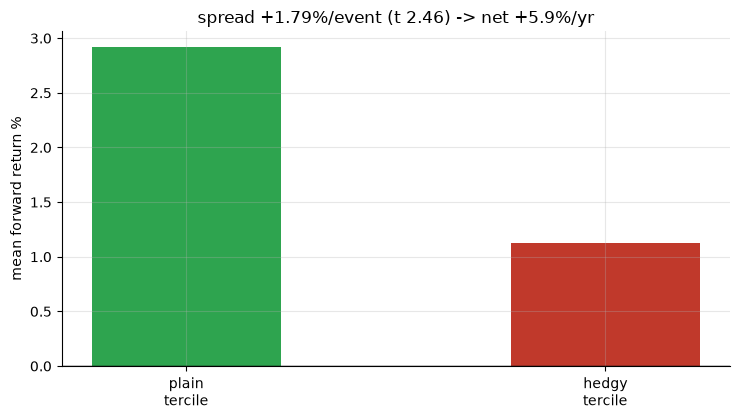

plain +2.92% | hedgy +1.13% | spread +1.79% (t 2.46)
gross +7.15%/yr -> net +5.85%/yr (5 bps/leg x 4 turns + 50 bps borrow)


In [5]:
ls = st.uncertainty_long_short(PANEL, 0.3)
gross_ann = ls['spread']*4*100
net_ann = st.net_spread(ls, turns_per_year=4.0, cost_bps=5.0, borrow_ann_bps=50.0)*100
fig, ax = plt.subplots(figsize=(7.5, 4.3))
ax.bar(['plain\ntercile','hedgy\ntercile'], [ls['plain_mean']*100, ls['hedgy_mean']*100],
       color=[GREEN, RED], width=.45)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('mean forward return %')
ax.set_title(f"spread {ls['spread']*100:+.2f}%/event (t {ls['t']:.2f}) -> net {net_ann:+.1f}%/yr")
plt.tight_layout(); plt.show()
print(f"plain {ls['plain_mean']*100:+.2f}% | hedgy {ls['hedgy_mean']*100:+.2f}% | spread {ls['spread']*100:+.2f}% (t {ls['t']:.2f})")
print(f"gross {gross_ann:+.2f}%/yr -> net {net_ann:+.2f}%/yr (5 bps/leg x 4 turns + 50 bps borrow)")

> 💡 In plain words: the book earns **+1.79%/event** (*t* 2.46), **+5.85%/yr** net — profitable *in the simulation*. But it's thin (quarterly), sign-unstable, and — the point — **not verified on real filings**. `FRAGILE`.

## 7 · Going further — the synthetic positive control

Is the engine a faithful detector, or does it always print a signal? Plant an uncertainty→vol link of increasing strength (`uncert_beta`) and watch the controlled slope-*t* rise from ≈ 0 at the null — averaged over 25 seeds so no single lucky seed can fake it.

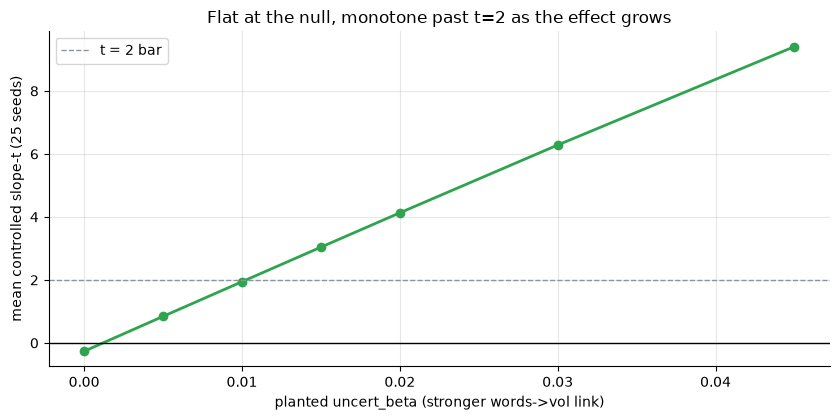

uncert_beta +0.000 -> mean controlled slope-t -0.26
uncert_beta +0.005 -> mean controlled slope-t +0.84
uncert_beta +0.010 -> mean controlled slope-t +1.94
uncert_beta +0.015 -> mean controlled slope-t +3.04
uncert_beta +0.020 -> mean controlled slope-t +4.13
uncert_beta +0.030 -> mean controlled slope-t +6.28
uncert_beta +0.045 -> mean controlled slope-t +9.41


In [6]:
betas = [0.0, 0.005, 0.010, 0.015, 0.020, 0.030, 0.045]
ts = [st.synthetic_mean_t(data, uncert_beta=b, n_seeds=25) for b in betas]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(betas, ts, 'o-', c=GREEN, lw=2)
ax.axhline(2, ls='--', c=GREY, lw=1, label='t = 2 bar')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted uncert_beta (stronger words->vol link)')
ax.set_ylabel('mean controlled slope-t (25 seeds)')
ax.set_title('Flat at the null, monotone past t=2 as the effect grows')
ax.legend(); plt.tight_layout(); plt.show()
for b, t in zip(betas, ts): print(f'uncert_beta {b:+.3f} -> mean controlled slope-t {t:+.2f}')

The controlled slope-*t* is ≈ 0 at the null (**-0.26**) and climbs monotonically past +2 as the planted link grows — so the engine is a faithful detector that *does not* print a false positive at the null. That's exactly why the real-tape gap matters: the machinery is ready, but with **no free feed of scored filings** the uncertainty-word signal stays `WEAK` on this desk. For the sentiment cousin, see [566 earnings-call-tone](../../566-earnings-call-tone/).